# E-COMMERCE CHURCN PREDICTION RANDOM FOREST

In [5]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### 1. Load Data

In [10]:
df = pd.read_csv('C:\\Users\\Bahar Arifianto\\OneDrive\\문서\\python workspace\\CSVFILE\\data_ecommerce_customer_churn.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (3941, 11)
   Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0    15.0             29.0                         4  Laptop & Accessory   
1     7.0             25.0                         4              Mobile   
2    27.0             13.0                         3  Laptop & Accessory   
3    20.0             25.0                         4             Fashion   
4    30.0             15.0                         4              Others   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  3        Single                2         0   
1                  1       Married                2         0   
2                  1       Married                5         0   
3                  3      Divorced                7         0   
4                  4        Single                8         0   

   DaySinceLastOrder  CashbackAmount  Churn  
0                7.0          143.32      0  
1                7.0          129.29      

### 2. Cek Missing Value

In [11]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


### 3. Preprocessing

In [22]:
# Isi missing value dengan median
df['Tenure']           = df['Tenure'].fillna(df['Tenure'].median())
df['WarehouseToHome']  = df['WarehouseToHome'].fillna(df['WarehouseToHome'].median())
df['DaySinceLastOrder']= df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median())
 
# Encode kolom kategorikal
le = LabelEncoder()
df['PreferedOrderCat'] = le.fit_transform(df['PreferedOrderCat'])
df['MaritalStatus']    = le.fit_transform(df['MaritalStatus'])

### 4. Split Fitur dan Target 

In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42,
                                                     stratify=y)

### 5. Training Model Random Forest

In [24]:
model = RandomForestClassifier(n_estimators=200, max_depth=10,
                               class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 6. Evaluasi Model

In [28]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
 
report = classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn'],
                                output_dict=True)
auc    = round(roc_auc_score(y_test, y_prob), 4)
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))
print(f"ROC-AUC Score: {auc}")


Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.95      0.95      0.95       654
       Churn       0.78      0.78      0.78       135

    accuracy                           0.92       789
   macro avg       0.87      0.87      0.87       789
weighted avg       0.92      0.92      0.92       789

ROC-AUC Score: 0.9538


### 7. Visualisasi

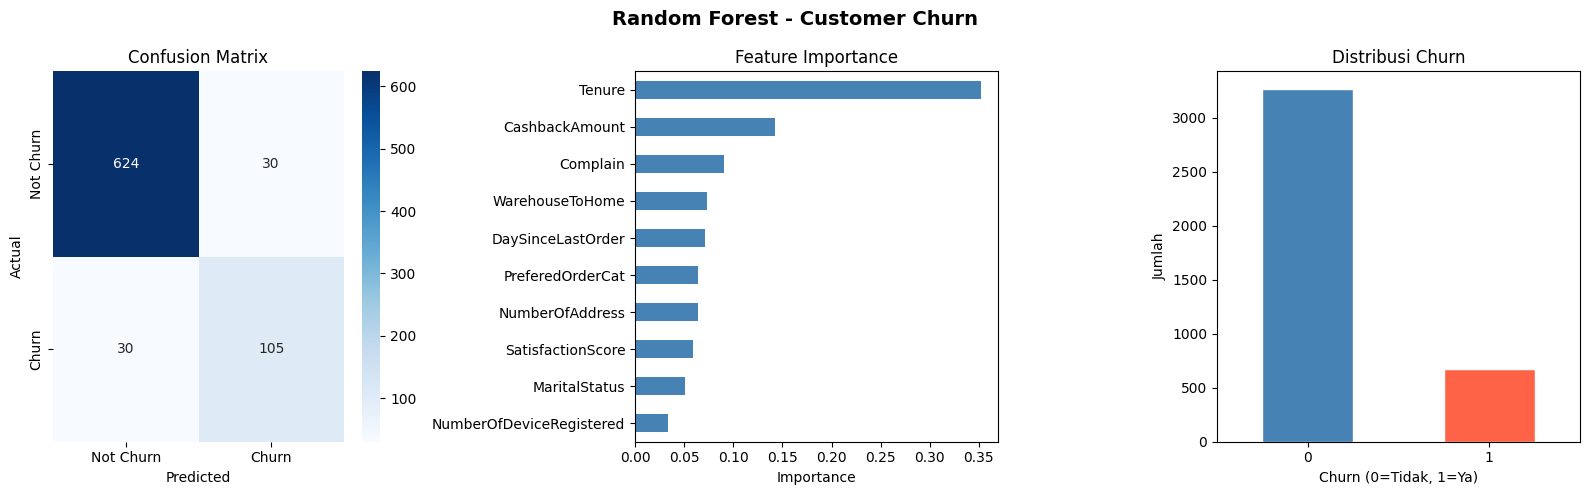

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest - Customer Churn", fontsize=14, fontweight='bold')
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
 
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance')
 
# Distribusi Churn
df['Churn'].value_counts().plot(kind='bar', ax=axes[2],
                                 color=['steelblue', 'tomato'],
                                 edgecolor='white')
axes[2].set_title('Distribusi Churn')
axes[2].set_xlabel('Churn (0=Tidak, 1=Ya)')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(rotation=0)
 
plt.tight_layout()
plt.savefig('hasil_churn.png', dpi=150)
plt.show()

### 8. Interpretasi

In [30]:
acc       = round(report['accuracy'] * 100, 1)
precision = round(report['Churn']['precision'] * 100, 1)
recall    = round(report['Churn']['recall'] * 100, 1)
f1        = round(report['Churn']['f1-score'] * 100, 1)
 
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(3)
 
print("\n" + "=" * 55)
print("  INTERPRETASI HASIL")
print("=" * 55)
print(f"""
Model Random Forest berhasil mengklasifikasikan pelanggan
yang akan churn dengan hasil sebagai berikut:
 
  Accuracy  : {acc}%
  → Model memprediksi dengan benar {acc} dari 100 pelanggan.
 
  Precision : {precision}% (kelas Churn)
  → Dari semua yang diprediksi churn, {precision}% benar-benar churn.
    Artinya tingkat false alarm model ini cukup rendah.
 
  Recall    : {recall}% (kelas Churn)
  → Dari semua pelanggan yang benar-benar churn, model
    berhasil mendeteksi {recall}%-nya.
 
  F1-Score  : {f1}% (kelas Churn)
  → Keseimbangan antara precision dan recall tergolong baik.
 
  ROC-AUC   : {auc}
  → Nilai mendekati 1 menunjukkan model sangat mampu
    membedakan pelanggan churn vs tidak churn.
 
Fitur paling berpengaruh terhadap prediksi Churn:""")
 
for i, (feat, val) in enumerate(top_features.items(), 1):
    print(f"  {i}. {feat:<30} (importance: {val:.3f})")
 
print(f"""
Kesimpulan:
  Pelanggan dengan Tenure rendah dan CashbackAmount kecil
  cenderung lebih berisiko churn. Selain itu, pelanggan yang
  pernah komplain memiliki kemungkinan churn jauh lebih tinggi.
  Model ini layak digunakan sebagai sistem peringatan dini
  untuk tim retention pelanggan.
""")
print("=" * 55)


  INTERPRETASI HASIL

Model Random Forest berhasil mengklasifikasikan pelanggan
yang akan churn dengan hasil sebagai berikut:

  Accuracy  : 92.4%
  → Model memprediksi dengan benar 92.4 dari 100 pelanggan.

  Precision : 77.8% (kelas Churn)
  → Dari semua yang diprediksi churn, 77.8% benar-benar churn.
    Artinya tingkat false alarm model ini cukup rendah.

  Recall    : 77.8% (kelas Churn)
  → Dari semua pelanggan yang benar-benar churn, model
    berhasil mendeteksi 77.8%-nya.

  F1-Score  : 77.8% (kelas Churn)
  → Keseimbangan antara precision dan recall tergolong baik.

  ROC-AUC   : 0.9538
  → Nilai mendekati 1 menunjukkan model sangat mampu
    membedakan pelanggan churn vs tidak churn.

Fitur paling berpengaruh terhadap prediksi Churn:
  1. Tenure                         (importance: 0.352)
  2. CashbackAmount                 (importance: 0.142)
  3. Complain                       (importance: 0.090)

Kesimpulan:
  Pelanggan dengan Tenure rendah dan CashbackAmount kecil
  cen